<a href="https://colab.research.google.com/github/olumayowaadeniyi68-arch/AVCAD-EXERCISE/blob/main/Exercise4_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import os

In [20]:
os.listdir()

['.config', 'EFIplus_medit.csv', 'sample_data']

In [21]:
os.listdir()

['.config', 'EFIplus_medit.csv', 'sample_data']

In [22]:
df = pd.read_csv(
    'EFIplus_medit.csv',
    sep=';'
)

df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [23]:
[col for col in df.columns
 if 'trutta' in str(col).lower()]

['Salmo trutta fario', 'Salmo trutta macrostigma']

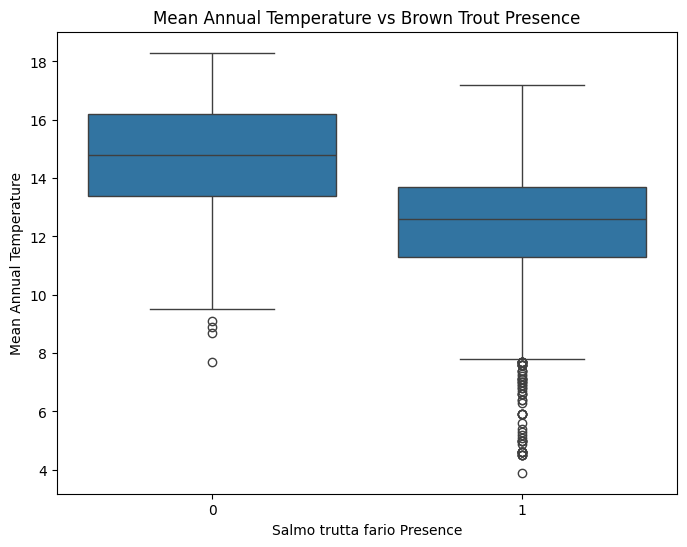

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Salmo trutta fario',
    y='temp_ann'
)

plt.title(
    'Mean Annual Temperature vs Brown Trout Presence'
)

plt.xlabel(
    'Salmo trutta fario Presence'
)

plt.ylabel(
    'Mean Annual Temperature'
)

plt.show()

# Exercise 1 Interpretation

The boxplot compares mean annual temperature between sites with and without Salmo trutta fario.

Brown trout are associated with colder water temperatures.

In [25]:
[col for col in df.columns
 if 'catch' in str(col).lower()]

['Catchment_name',
 'Elevation_mean_catch',
 'prec_ann_catch',
 'Barriers_catchment_down']

In [26]:
filtered_df = df[
    df['Catchment_name'].isin(
        ['Minho', 'Tagus']
    )
]

filtered_df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1759,ES_35_0562,43.250639,-7.320337,Spain,Minho,1,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1760,ES_35_0563,43.261115,-7.371032,Spain,Minho,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1761,ES_35_0564,43.258076,-7.398143,Spain,Minho,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1762,ES_35_0565,43.240407,-7.435728,Spain,Minho,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1763,ES_35_0566,43.206242,-7.439544,Spain,Minho,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


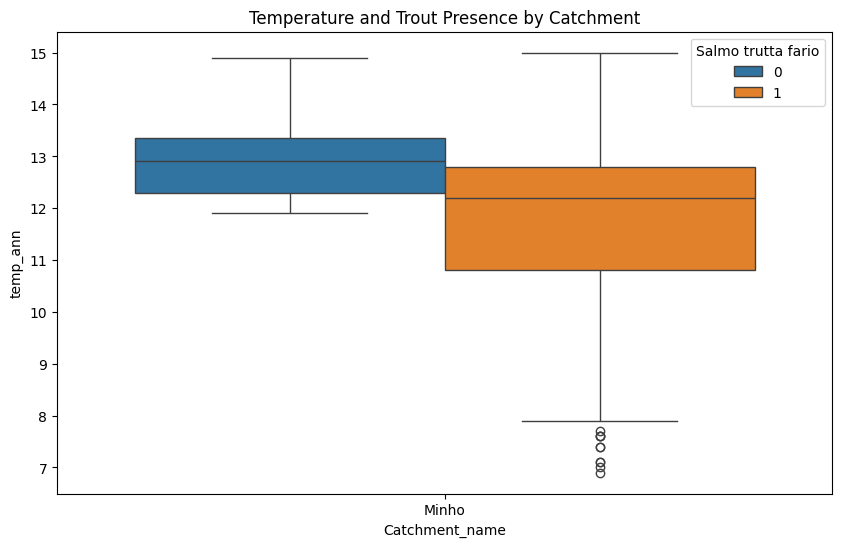

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=filtered_df,
    x='Catchment_name',
    y='temp_ann',
    hue='Salmo trutta fario'
)

plt.title(
    'Temperature and Trout Presence by Catchment'
)

plt.show()

# Exercise 2 Interpretation

The visualization compares the effect of temperature on trout presence between Minho and Tagus catchments.

Differences between boxplots suggest different effect sizes.

In [28]:
[col for col in df.columns
 if 'slope' in str(col).lower()]

['Actual_river_slope']

In [29]:
slope_data = pd.to_numeric(
    df['Actual_river_slope'],
    errors='coerce'
)

slope_data = slope_data.dropna()

slope_data.head()

,Actual_river_slope
0,0.001
1,13.406
2,9.398
3,8.186
4,11.736


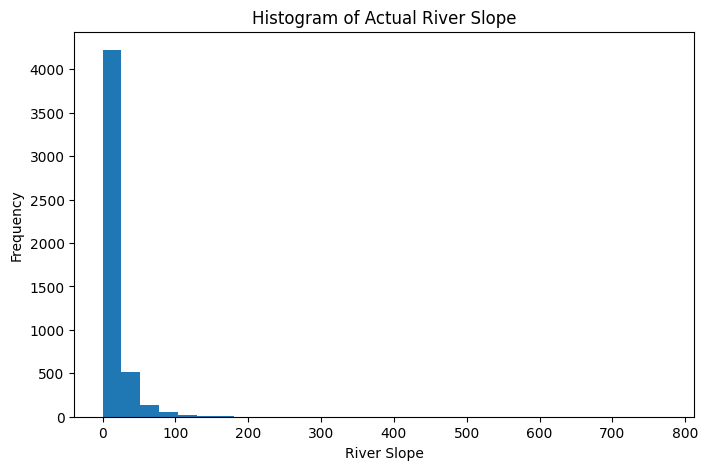

In [30]:
plt.figure(figsize=(8,5))

plt.hist(
    slope_data,
    bins=30
)

plt.title(
    'Histogram of Actual River Slope'
)

plt.xlabel('River Slope')

plt.ylabel('Frequency')

plt.show()

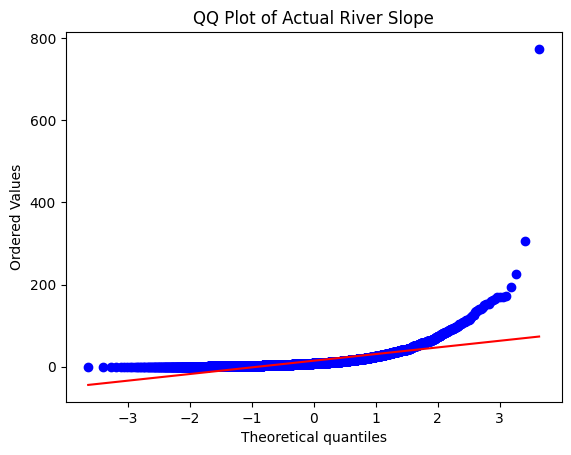

In [31]:
stats.probplot(
    slope_data,
    dist='norm',
    plot=plt
)

plt.title(
    'QQ Plot of Actual River Slope'
)

plt.show()

In [32]:
sample_for_test = slope_data.sample(
    500,
    random_state=42
)

stats.shapiro(
    sample_for_test
)

ShapiroResult(statistic=np.float64(0.6769683630820849), pvalue=np.float64(9.242386577167637e-30))

# Exercise 3 Interpretation

The histogram and QQ plot visually assess normality.

The Shapiro-Wilk test formally tests whether actual river slope follows a normal distribution.

In [33]:
sample_means = []

for i in range(100):

    sample = slope_data.sample(
        n=2000,
        replace=True,
        random_state=i
    )

    sample_means.append(
        sample.mean()
    )

sample_means[:5]

[np.float64(15.4051975),
 np.float64(15.074221999999999),
 np.float64(13.9180705),
 np.float64(14.599818500000001),
 np.float64(14.587943)]

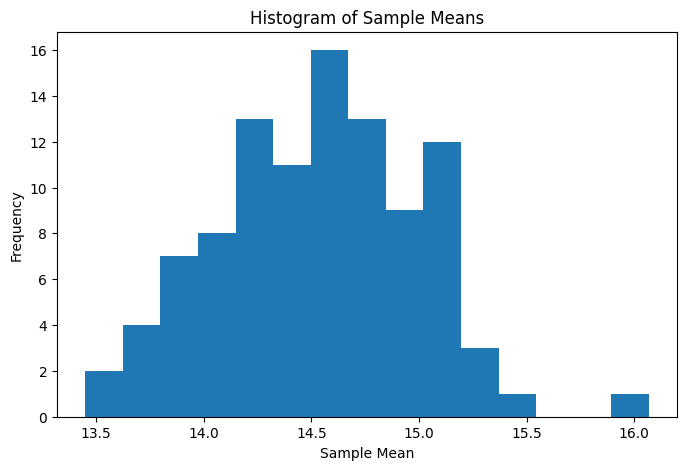

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    sample_means,
    bins=15
)

plt.title(
    'Histogram of Sample Means'
)

plt.xlabel('Sample Mean')

plt.ylabel('Frequency')

plt.show()

In [35]:
stats.shapiro(sample_means)

ShapiroResult(statistic=np.float64(0.9882177624713449), pvalue=np.float64(0.5244000305096395))

# Final Conclusion

This exercise explored:
- ecological visualization
- trout-temperature relationships
- catchment comparisons
- normality testing
- sampling distributions
- the Central Limit Theorem

The sample means appear more normally distributed than the original data.